# 01 — Production shortfall diagnostics agent

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/AI/community_agent_demos/01_production_shortfall_diagnostics_agent.ipynb)

Reconcile a production loss, rank physical hypotheses, and produce an evidence-and-action package.

This is a **synthetic public demonstration**, not an autonomous-control
system. The agent prepares a traceable engineering screening package;
a qualified engineer owns assumptions, validation, and decisions.


## Agent contract

**Inputs:** validated hourly tags, operating events, fluid
composition, and a healthy reference window. **Outputs:** allocated
loss, ranked hypotheses, discriminating checks, and uncertainty.

The screening model is $r = S a + \epsilon$, where $r$ is the
normalized residual vector, columns of $S$ are fault signatures,
and non-negative amplitudes $a$ are estimated from the data.

Deep dive: [model versus measurement](../../process/digital_twin_model_vs_measurement.ipynb).


In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import os
import platform
import subprocess
import sys


REQUIRED_PACKAGES = {
    "neqsim": "3.17.0",
    "numpy": "2.5.2",
    "pandas": "3.0.5",
    "matplotlib": "3.11.1",
    "scipy": "1.18.0",
}
install_specs = []
for package_name, required_version in REQUIRED_PACKAGES.items():
    try:
        installed_version = version(package_name)
    except PackageNotFoundError:
        installed_version = None
    if installed_version != required_version:
        install_specs.append(f"{package_name}=={required_version}")

if install_specs:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            *install_specs,
        ],
        check=True,
    )

NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")
RUNTIME_DEPENDENCY_JAR = os.environ.get("NEQSIM_RUNTIME_DEPENDENCY_JAR")
using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ

if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
    SOURCE_BUILD_KIND = os.environ.get(
        "NEQSIM_SOURCE_BUILD_KIND", "prebuilt source JAR override"
    )
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in ("sources", "javadoc", "tests", "original")
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master source build did not produce a runtime JAR."
        )
    SOURCE_JAR = sorted(jar_candidates, key=lambda path: len(path.name))[0]
    SOURCE_BUILD_KIND = "Maven package from current master"

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-agent-demo-matplotlib")

import jpype


if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the NeqSim master JAR was selected. "
        "Restart the runtime and run all cells."
    )

jpype.addClassPath(str(SOURCE_JAR))
if RUNTIME_DEPENDENCY_JAR:
    jpype.addClassPath(str(Path(RUNTIME_DEPENDENCY_JAR).resolve()))
from neqsim.neqsimpython import init_jvm


init_jvm()
SOURCE_PROBE = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
DESIGN_PROBE = jpype.JClass(
    "neqsim.process.engineering.design.EngineeringDesignLoop"
)
LOADED_JAR_LOCATION = str(
    SOURCE_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
DESIGN_JAR_LOCATION = str(
    DESIGN_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION
assert SOURCE_JAR.name in DESIGN_JAR_LOCATION

print(f"NeqSim Python bridge: {version('neqsim')}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Source build: {SOURCE_BUILD_KIND}")
print(f"Loaded thermodynamics from: {LOADED_JAR_LOCATION}")
print(f"Python runtime: {platform.python_version()}")


NeqSim Python bridge: 3.17.0
NeqSim source ref: master
NeqSim source commit: 1dee5b51f6689d0b383e8d90fece9729132dd6e3
NeqSim source JAR SHA-256: f3e4080d8e6a97225047de1ec04c5a7fcd1049845b770a11da4986d96d2dce8c
Source build: javac source overlay from exact master Java sources
Loaded thermodynamics from: file:/workspace/scratch/6d0c0fad8be4/neqsim-master/target/neqsim-current-master-agent-demo-complete.jar
Python runtime: 3.12.13


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from IPython.display import display
from neqsim.thermo import TPflash, fluid


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})
RNG = np.random.default_rng(42)


def flash_state(composition, pressure_bara, temperature_c, model="srk"):
    """Return a compact, unit-labelled NeqSim flash result."""
    system = fluid(model)
    for component, fraction in composition.items():
        system.addComponent(component, float(fraction))
    system.setMixingRule(2)
    system.setMultiPhaseCheck(True)
    system.setPressure(float(pressure_bara), "bara")
    system.setTemperature(float(temperature_c), "C")
    TPflash(system)
    system.initProperties()
    phases = []
    for phase_index in range(system.getNumberOfPhases()):
        phase = system.getPhase(phase_index)
        phases.append(
            {
                "phase": str(phase.getPhaseTypeName()),
                "beta_mol": float(phase.getBeta()),
                "density_kg_m3": float(phase.getDensity("kg/m3")),
            }
        )
    return {
        "system": system,
        "pressure_bara": pressure_bara,
        "temperature_c": temperature_c,
        "density_kg_m3": float(system.getDensity("kg/m3")),
        "viscosity_pa_s": float(system.getViscosity("kg/msec")),
        "z_factor": float(system.getZ()),
        "molar_mass_kg_mol": float(system.getMolarMass("kg/mol")),
        "cp_j_kg_k": float(system.getCp("J/kgK")),
        "cv_j_kg_k": float(system.getCv("J/kgK")),
        "phases": phases,
    }


NORTHSTAR_GAS = {
    "methane": 0.820,
    "ethane": 0.075,
    "propane": 0.035,
    "i-butane": 0.010,
    "n-butane": 0.015,
    "n-heptane": 0.020,
    "CO2": 0.015,
    "nitrogen": 0.010,
}


In [3]:
reference = flash_state(NORTHSTAR_GAS, 85.0, 38.0)
display(pd.DataFrame(reference["phases"]))
print(
    f"Reference density={reference['density_kg_m3']:.2f} kg/m3, "
    f"Z={reference['z_factor']:.3f}"
)


Reference density=86.93 kg/m3, Z=0.812


,phase,beta_mol,density_kg_m3
0,gas,0.964333,79.894767
1,oil,0.035667,547.332992


In [4]:
hours = np.arange(0.0, 48.0, 1.0)
healthy_rate = 18.0 * (1.0 + 0.012 * np.sin(hours / 5.0))
restriction = np.where(hours >= 24.0, 0.075, 0.0)
meter_bias = np.where(hours >= 38.0, 0.018, 0.0)
measured_rate = healthy_rate * (1.0 - restriction - meter_bias)
measured_rate += RNG.normal(0.0, 0.05, hours.size)
flowline_dp = 10.0 + 85.0 * restriction + RNG.normal(0.0, 0.12, hours.size)
power_per_rate = 0.42 + 0.18 * restriction + RNG.normal(0.0, 0.004, hours.size)
allocation_gap = meter_bias + RNG.normal(0.0, 0.002, hours.size)

tags = pd.DataFrame(
    {
        "hour": hours,
        "healthy_rate_kg_s": healthy_rate,
        "measured_rate_kg_s": measured_rate,
        "flowline_dp_bar": flowline_dp,
        "power_per_rate": power_per_rate,
        "allocation_gap_fraction": allocation_gap,
    }
)
display(tags.tail())


,hour,healthy_rate_kg_s,measured_rate_kg_s,flowline_dp_bar,power_per_rate,allocation_gap_fraction
43,43.0,18.158630,16.481485,16.363182,0.445155,0.015551
44,44.0,18.126342,16.446427,16.324204,0.435158,0.015264
45,45.0,18.089018,16.417673,16.365434,0.429542,0.021302
46,46.0,18.048144,16.413238,16.172520,0.424972,0.021447
47,47.0,18.005351,16.342034,16.201347,0.434571,0.017641


In [5]:
healthy = tags.query("hour < 20")
current = tags.query("hour >= 40")
residual = np.array(
    [
        1.0 - current.measured_rate_kg_s.mean()
        / current.healthy_rate_kg_s.mean(),
        (current.flowline_dp_bar.mean() - healthy.flowline_dp_bar.mean()) / 80.0,
        (current.power_per_rate.mean() - healthy.power_per_rate.mean()) / 0.20,
        current.allocation_gap_fraction.mean(),
    ]
)
hypotheses = [
    "well inflow loss",
    "flowline restriction",
    "compressor degradation",
    "meter or allocation bias",
]
signatures = np.array(
    [
        [0.95, 0.15, 0.10, 0.05],
        [0.70, 0.95, 0.45, 0.05],
        [0.40, 0.05, 0.95, 0.05],
        [0.85, 0.00, 0.00, 1.00],
    ]
).T
amplitudes, fit_residual = optimize.nnls(signatures, residual)
result = pd.DataFrame(
    {"hypothesis": hypotheses, "estimated_amplitude": amplitudes}
).sort_values("estimated_amplitude", ascending=False)
result["evidence"] = [
    "rate + pressure-drop signature",
    "material-balance mismatch",
    "rate-only response",
    "specific-power signature",
]
allocated_loss_kg_s = healthy_rate[-1] * amplitudes.sum()
display(result)
print(f"Unexplained normalized residual: {fit_residual:.4f}")
print(f"Allocated loss: {allocated_loss_kg_s:.2f} kg/s")


Unexplained normalized residual: 0.0000
Allocated loss: 2.66 kg/s


,hypothesis,estimated_amplitude,evidence
1,flowline restriction,0.079816,rate + pressure-drop signature
2,compressor degradation,0.049061,material-balance mismatch
3,meter or allocation bias,0.011896,rate-only response
0,well inflow loss,0.006953,specific-power signature


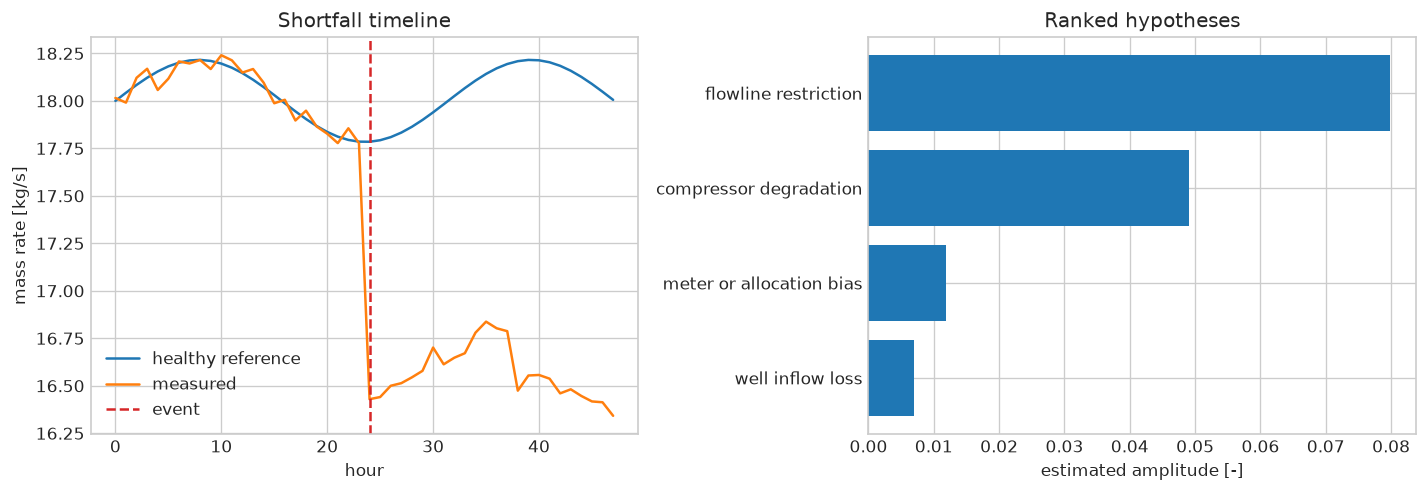

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(hours, healthy_rate, label="healthy reference")
axes[0].plot(hours, measured_rate, label="measured")
axes[0].axvline(24, color="tab:red", linestyle="--", label="event")
axes[0].set(xlabel="hour", ylabel="mass rate [kg/s]", title="Shortfall timeline")
axes[0].legend()
axes[1].barh(result.hypothesis, result.estimated_amplitude)
axes[1].invert_yaxis()
axes[1].set(xlabel="estimated amplitude [-]", title="Ranked hypotheses")
plt.tight_layout()
plt.show()


In [7]:
meter_amplitude = result.loc[
    result.hypothesis == "meter or allocation bias",
    "estimated_amplitude",
].iloc[0]
assert result.iloc[0].hypothesis == "flowline restriction"
assert meter_amplitude > 0.01
assert allocated_loss_kg_s > 1.0
print("VALIDATION PASSED")
print("Next checks: inspect flowline DP and perform an allocation-meter comparison.")


VALIDATION PASSED
Next checks: inspect flowline DP and perform an allocation-meter comparison.


## Interpretation and limits

The agent identifies a restriction as the primary cause and a smaller
allocation bias. Signature matching is diagnostic triage, not proof:
tag quality, common-cause failures, and alternative operating modes
must be reviewed before intervention.
